# This notebook includes a Deceptive Max Ones implementation

In [ ]:
import random
import numpy
import matplotlib.pyplot as plt
from deap import algorithms, base, creator, tools

In [ ]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=18)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

The only thing we need to do is change the evaluation function so that it works in blocks of three, like this.

In [ ]:
def evalOneMaxDeceptive(individual):
    fitness = 0

    for i in range(0, len(individual), 3):
        indlen = sum(individual[i:i + 3])
        if indlen == 0:
            fitness += 0.9
        elif indlen == 1:
            fitness += 0.8
        elif indlen == 2:
            fitness += 0.0
        else:
            fitness += 1.0

    return (fitness,)

In [ ]:
toolbox.register("evaluate", evalOneMaxDeceptive)
toolbox.register("select", tools.selTournament, tournsize=3)

#toolbox.register("mate", tools.cxUniform, indpb=0.1)
toolbox.register("mate", tools.cxTwoPoint)

toolbox.register("mutate", tools.mutFlipBit, indpb=0.01)

In [ ]:
logbook = tools.Logbook()
stats = tools.Statistics(key=lambda ind: ind.fitness.values)
stats.register("avg", numpy.mean)
stats.register("std", numpy.std)
stats.register("min", numpy.min)
stats.register("max", numpy.max)

In [ ]:
pop = toolbox.population(n=100)
fitnesses = list(map(toolbox.evaluate, pop))
for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit

In [ ]:
NGEN = 100
for g in range(NGEN):
    print("-- Generation %i --" % g)

    offspring = toolbox.select(pop, len(pop))
    offspring = list(map(toolbox.clone, offspring))

    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        toolbox.mate(child1, child2)
        del child1.fitness.values
        del child2.fitness.values

    for mutant in offspring:
        toolbox.mutate(mutant)
        del mutant.fitness.values

    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
         ind.fitness.values = fit

    pop[:] = offspring

    record = stats.compile(pop)
    logbook.record(gen=g, **record)

In [ ]:
logbook.header = "gen", "avg", "std", "min", "max"
gen = logbook.select("gen")
avgs = logbook.select("avg")
stds = logbook.select("std")

Text(0, 0.5, 'Mean Fitness')

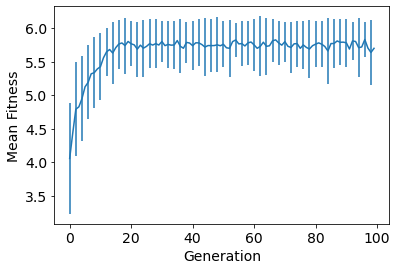

In [ ]:
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
fig, ax1 = plt.subplots()
#line1 = ax1.plot(gen, avgs)
line1 = ax1.errorbar(gen, avgs, yerr=stds, errorevery=2)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Mean Fitness")

In [ ]:
print(logbook)

In [ ]:
gen	avg  	std     	min	max
0  	4.053	0.827702	1.6	5.5
1  	4.431	0.731669	2.4	5.5
2  	4.787	0.703087	2.4	5.6
3  	4.824	0.584486	2.9	5.6

In [ ]:
print(pop[0])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1]


Note that you tend to end up at a local maximum where you have chunks of 3 1s and chunks of 3 0s throughout. This is because there is no clean 'gradient' to climb. A hillclimber and other local-search methods struggle even more with these kinds of problems.